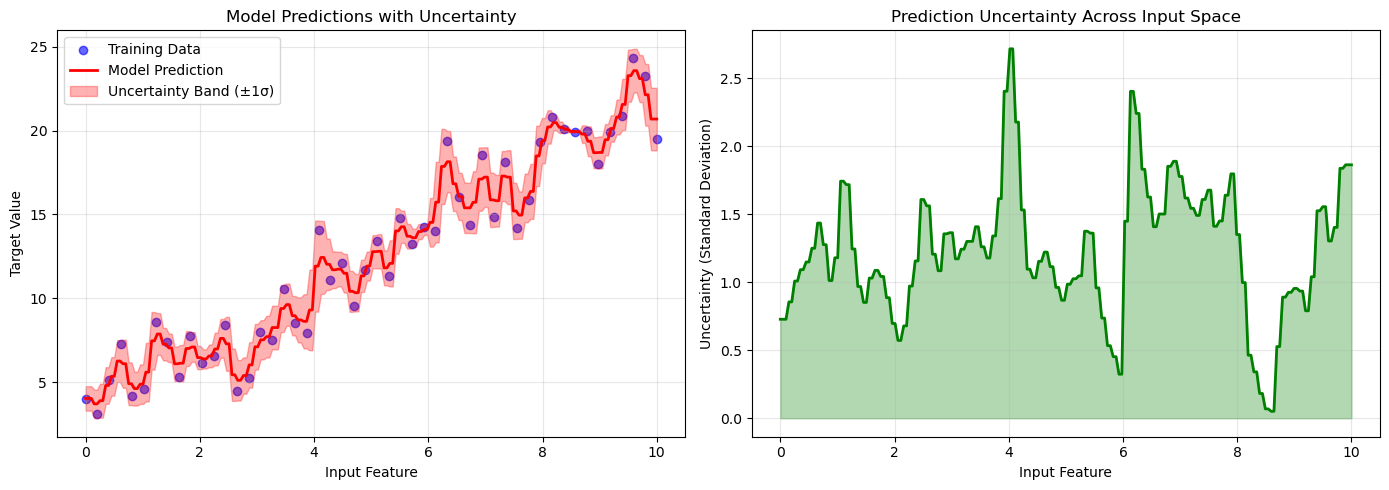

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Generate sample data with noise
np.random.seed(42)
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 2 * X.flatten() + 3 + np.random.normal(0, 2, 50)  # True line: y = 2x + 3

# Create test points
X_test = np.linspace(0, 10, 200).reshape(-1, 1)

# Fit model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Predictions with uncertainty estimation
predictions = model.predict(X_test)

# Estimate uncertainty using prediction variance (ensemble method)
# Using individual tree predictions for uncertainty
uncertainty_samples = np.array([tree.predict(X_test) for tree in model.estimators_])
mean_predictions = np.mean(uncertainty_samples, axis=0)
std_uncertainty = np.std(uncertainty_samples, axis=0)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Model predictions with uncertainty bands
axes[0].scatter(X, y, alpha=0.6, label='Training Data', color='blue')
axes[0].plot(X_test, mean_predictions, 'r-', linewidth=2, label='Model Prediction')
axes[0].fill_between(X_test.flatten(), 
                     mean_predictions - std_uncertainty,
                     mean_predictions + std_uncertainty,
                     alpha=0.3, color='red', label='Uncertainty Band (±1σ)')
axes[0].set_xlabel('Input Feature')
axes[0].set_ylabel('Target Value')
axes[0].set_title('Model Predictions with Uncertainty')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Uncertainty magnitude across input space
axes[1].plot(X_test, std_uncertainty, 'g-', linewidth=2)
axes[1].fill_between(X_test.flatten(), 0, std_uncertainty, alpha=0.3, color='green')
axes[1].set_xlabel('Input Feature')
axes[1].set_ylabel('Uncertainty (Standard Deviation)')
axes[1].set_title('Prediction Uncertainty Across Input Space')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('uncertainty_modeling.png', dpi=150)
plt.show()

#print("Chart saved as 'uncertainty_modeling.png'")